In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_data():
  data = pd.read_excel("Folds5x2_pp.xlsx")
  return data

data = load_data()
print(data.head())
print(data.describe())
print(data.shape)
print(data.columns)

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.940000    74.975000   451.550000
75%      25.720000    66.540000  1017.260000    84.830000   468.430000
max      37.110000    81.560000  1033.300000   100.160000   495.760000
(9568, 5)
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')


In [3]:
def process_data():
  data = load_data()
  X = data[["AT", "V", "AP", "RH"]].values
  y = data["PE"].values
  return X, y

X, y = process_data()
print(X.shape)
print(y.shape)

(9568, 4)
(9568,)


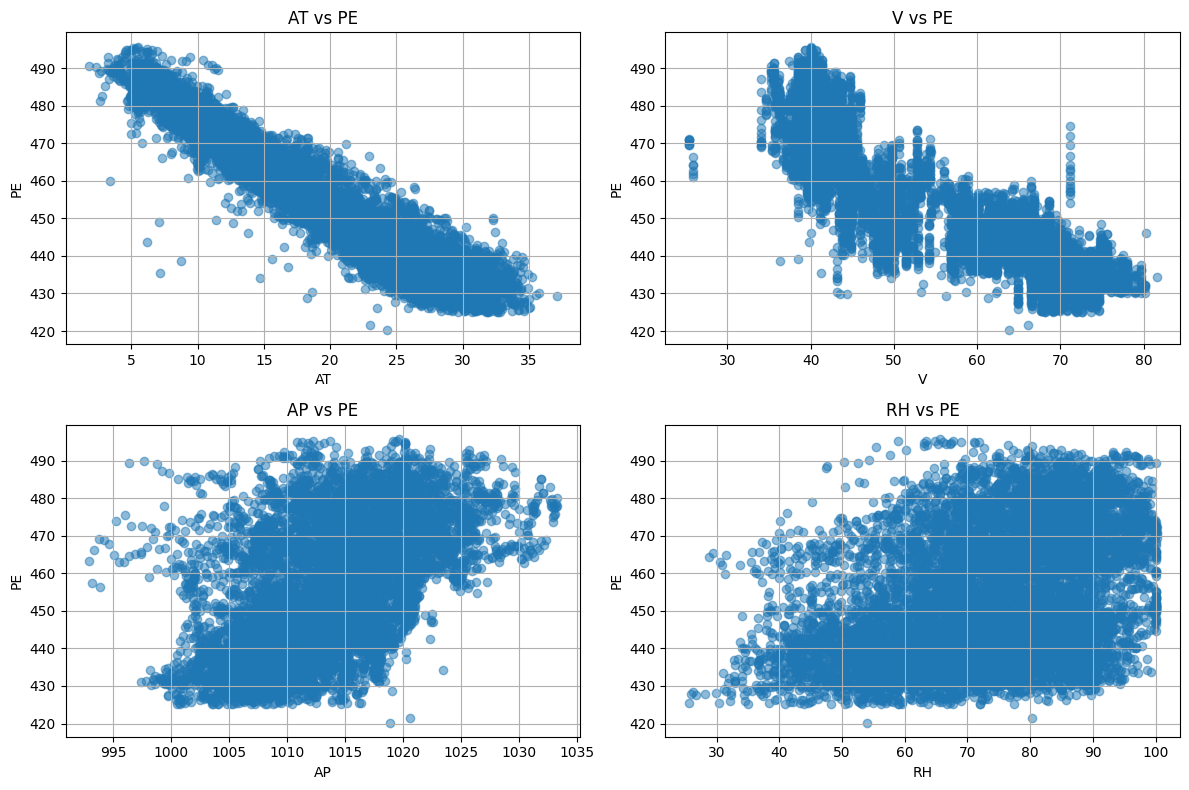

In [4]:
def feature_plotting():
    features = ["AT", "V", "AP", "RH"]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for ax, feature in zip(axes.ravel(), features):
        ax.scatter(data[feature], data["PE"], alpha=0.5)
        ax.set_xlabel(feature)
        ax.set_ylabel("PE")
        ax.set_title(f"{feature} vs PE")
        ax.grid(True)

    plt.tight_layout()
    plt.show()

feature_plotting()

In [5]:
from sklearn.model_selection import train_test_split

def split_data():
  X, y = process_data()
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
  return X_train, X_val, y_train, y_val

X_train, X_val, y_train, y_val = split_data()
print(X_train.shape)
print(X_val.shape)

(7654, 4)
(1914, 4)


In [6]:
def normalize_features(X_train, X_val):
    mean = np.mean(X_train, axis=0)
    std = np.std(X_train, axis=0)

    X_train_normalized = (X_train - mean) / std
    X_val_normalized = (X_val - mean) / std

    return X_train_normalized, X_val_normalized

X_train_normalized, X_val_normalized = normalize_features(X_train, X_val)

In [7]:
def add_bias(X):
  return np.c_[np.ones(X.shape[0]), X]

X_train = add_bias(X_train)
X_val = add_bias(X_val)

print(X_train.shape)
print(X_val.shape)

(7654, 5)
(1914, 5)


In [8]:
def predict(X, theta):
    return X @ theta

In [9]:
def compute_cost(X, y, theta):
  m = len(y)
  y_pred = predict(X, theta)
  error = y_pred - y
  cost = (1 / (2*m))*np.sum(error**2)
  return cost

In [10]:
def gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    alpha,
    iterations
):
    m = len(y_train)

    train_errors = []
    val_errors = []

    for i in range(iterations):

        # Training prediction
        predictions = predict(X_train, theta)

        # Training error
        errors = predictions - y_train

        # Gradient
        gradient = (1 / m) * (X_train.T @ errors)

        # Update parameters
        theta = theta - alpha * gradient

        # Record training error
        train_cost = compute_cost(X_train, y_train, theta)

        # Record validation error
        val_cost = compute_cost(X_val, y_val, theta)

        train_errors.append(train_cost)
        val_errors.append(val_cost)

    return theta, train_errors, val_errors

In [11]:
theta = np.zeros(X_train.shape[1])

alpha = 0.000001
iterations = 1000

theta, train_errors, val_errors = gradient_descent(
    X_train,
    y_train,
    X_val,
    y_val,
    theta,
    alpha,
    iterations
)

In [12]:
best_val_error = min(val_errors)
best_iteration = np.argmin(val_errors)

best_train_error = train_errors[best_iteration]

print("Best validation error:", best_val_error)
print("Training error at best validation:", best_train_error)
print("Best iteration:", best_iteration)
print("Parameters:", theta)

Best validation error: 87.01632582600155
Training error at best validation: 87.59191924328735
Best iteration: 999
Parameters: [ 4.11225049e-04 -9.10366025e-02 -1.35302902e-01  4.50089105e-01
  1.02641418e-01]


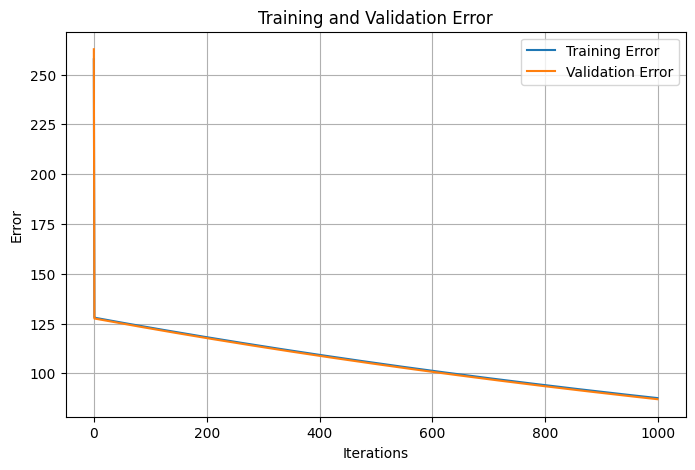

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(train_errors, label="Training Error")
plt.plot(val_errors, label="Validation Error")

plt.xlabel("Iterations")
plt.ylabel("Error")
plt.title("Training and Validation Error")
plt.legend()
plt.grid()

plt.show()

In [14]:
print("Training mean:")
print(X_train_normalized.mean(axis=0))

print("\nTraining std:")
print(X_train_normalized.std(axis=0))

Training mean:
[ 8.94386617e-17 -1.64251506e-14  2.44766130e-13  1.16792735e-14]

Training std:
[1. 1. 1. 1.]


In [15]:
X_train_scaled = add_bias(X_train_normalized)
X_val_scaled = add_bias(X_val_normalized)

In [16]:
theta_scaled = np.zeros(X_train_scaled.shape[1])

theta_scaled, train_errors_scaled, val_errors_scaled = gradient_descent(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    theta_scaled,
    alpha=0.01,
    iterations=1000
)

In [17]:
best_val_scaled = min(val_errors_scaled)
best_iter_scaled = np.argmin(val_errors_scaled)

print("Best validation error:", best_val_scaled)
print("Training error:", train_errors_scaled[best_iter_scaled])
print("Parameters:", theta_scaled)

Best validation error: 10.703909122150035
Training error: 11.130485900045676
Parameters: [454.41142162 -11.95688897  -5.01755986   0.89716101  -1.38319795]


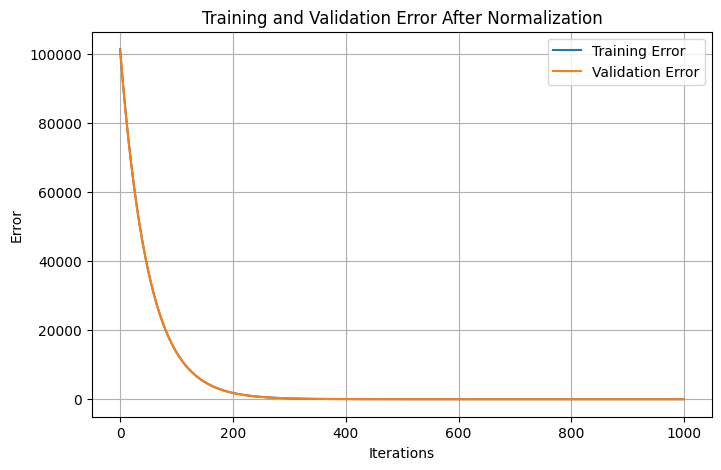

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(train_errors_scaled, label="Training Error")
plt.plot(val_errors_scaled, label="Validation Error")

plt.xlabel("Iterations")
plt.ylabel("Error")
plt.title("Training and Validation Error After Normalization")
plt.legend()
plt.grid()

plt.show()

In [19]:
from sklearn.model_selection import KFold

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [20]:
def k_fold_cross_validation(
    X,
    y,
    k=5,
    alpha=0.01,
    iterations=1000
):
    kf = KFold(
        n_splits=k,
        shuffle=True,
        random_state=42
    )

    fold_errors = []
    fold_parameters = []

    for fold, (train_index, val_index) in enumerate(
        kf.split(X),
        start=1
    ):

        X_train = X[train_index]
        X_val = X[val_index]

        y_train = y[train_index]
        y_val = y[val_index]

        # Normalize using training fold only
        X_train, X_val = normalize_features(
            X_train,
            X_val
        )

        # Add intercept
        X_train = add_bias(X_train)
        X_val = add_bias(X_val)

        # Initialize parameters
        theta = np.zeros(X_train.shape[1])

        # Train
        theta, train_errors, val_errors = gradient_descent(
            X_train,
            y_train,
            X_val,
            y_val,
            theta,
            alpha,
            iterations
        )

        # Best validation error
        best_val_error = min(val_errors)

        fold_errors.append(best_val_error)
        fold_parameters.append(theta)

        print(
            f"Fold {fold}: "
            f"Best validation error = {best_val_error:.4f}"
        )

    return fold_errors, fold_parameters

In [21]:
fold_errors, fold_parameters = k_fold_cross_validation(
    X,
    y,
    k=5,
    alpha=0.01,
    iterations=1000
)

average_error = np.mean(fold_errors)

best_fold_index = np.argmin(fold_errors)

print("\nAverage CV Error:", average_error)

print(
    "Best Fold:",
    best_fold_index + 1
)

print(
    "Best Validation Error:",
    fold_errors[best_fold_index]
)

print(
    "Best Parameters:",
    fold_parameters[best_fold_index]
)

Fold 1: Best validation error = 10.7039
Fold 2: Best validation error = 11.1324
Fold 3: Best validation error = 11.6545
Fold 4: Best validation error = 11.1020
Fold 5: Best validation error = 10.8117

Average CV Error: 11.080913480366215
Best Fold: 1
Best Validation Error: 10.703909122147238
Best Parameters: [454.41142162 -11.95688897  -5.01755986   0.89716101  -1.38319795]


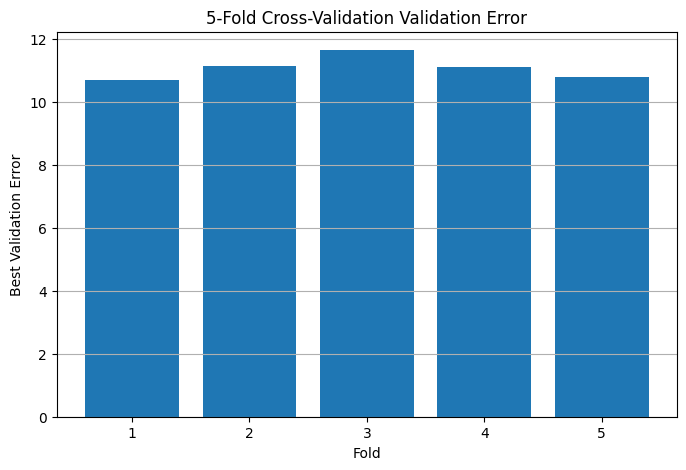

In [22]:
import matplotlib.pyplot as plt

fold_numbers = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))
plt.bar(fold_numbers, fold_errors)

plt.xlabel("Fold")
plt.ylabel("Best Validation Error")
plt.title("5-Fold Cross-Validation Validation Error")
plt.xticks(fold_numbers)
plt.grid(axis="y")

plt.show()

In [23]:
data = pd.read_csv("data_02b.csv")

print(data.head())
print(data.shape)
print(data.columns)

   130.0  18.0
0  165.0  15.0
1  150.0  18.0
2  150.0  16.0
3  140.0  17.0
4  198.0  15.0
(391, 2)
Index(['130.0', '18.0'], dtype='object')


In [24]:
X = data.iloc[:, 0].values
y = data.iloc[:, 1].values

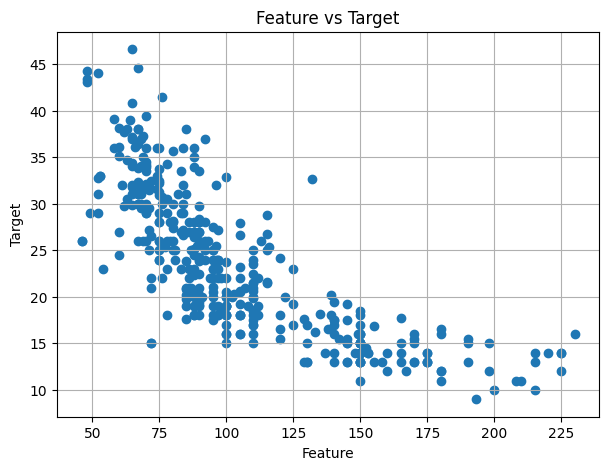

In [25]:
plt.figure(figsize=(7, 5))

plt.scatter(X, y)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Feature vs Target")

plt.grid()
plt.show()

In [26]:
def create_polynomial_features(X, degree):
    X_poly = np.column_stack(
        [X ** i for i in range(1, degree + 1)]
    )

    return X_poly

In [30]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
results = {}

for degree in [1, 2, 3]:

    # Create polynomial features
    X_train_poly = create_polynomial_features(
        X_train_raw,
        degree
    )

    X_val_poly = create_polynomial_features(
        X_val_raw,
        degree
    )

    # Normalize
    X_train_poly, X_val_poly = normalize_features(
        X_train_poly,
        X_val_poly
    )

    # Add intercept
    X_train_poly = add_bias(X_train_poly)
    X_val_poly = add_bias(X_val_poly)

    # Initialize theta
    theta = np.zeros(X_train_poly.shape[1])

    # Train
    theta, train_errors, val_errors = gradient_descent(
        X_train_poly,
        y_train,
        X_val_poly,
        y_val,
        theta,
        alpha=0.01,
        iterations=1000
    )

    # Find best validation error
    best_index = np.argmin(val_errors)

    results[degree] = {
        "theta": theta,
        "train_errors": train_errors,
        "val_errors": val_errors,
        "best_val_error": val_errors[best_index],
        "best_train_error": train_errors[best_index]
    }

    print(f"\nDegree {degree}")
    print("----------------")
    print("Best validation error:",
          val_errors[best_index])
    print("Training error:",
          train_errors[best_index])
    print("Theta:", theta)


Degree 1
----------------
Best validation error: 12.683060361163832
Training error: 11.956151263653789
Theta: [23.60699363 -6.21633998]

Degree 2
----------------
Best validation error: 12.931076842073798
Training error: 12.130333764891436
Theta: [23.60699363 -5.34256205 -0.67020367]

Degree 3
----------------
Best validation error: 11.42027718139304
Training error: 11.098637196534492
Theta: [23.60699363 -6.21535168 -1.71418111  2.1260731 ]
